# Performance analysis

Just on final models

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

In [4]:
cwd = Path.cwd().resolve()
project_root = cwd.parents[1]

output_dir = project_root / "transferability" / "outputs" / "final_models"

print("project_root:", project_root)
print("output_dir:", output_dir)
print("files:")
for path in sorted(output_dir.glob("*.csv")):
    print("-", path.name)

project_root: /Users/yannis/as1
output_dir: /Users/yannis/as1/transferability/outputs/final_models
files:
- model_comparison_2025.csv
- random_forest_benchmark_feature_importance.csv
- random_forest_benchmark_predictions_2025.csv
- xgboost_retained_feature_importance.csv
- xgboost_retained_predictions_2025.csv


## Read results

In [5]:
comparison = pd.read_csv(output_dir / "model_comparison_2025.csv")
rf_predictions = pd.read_csv(output_dir / "random_forest_benchmark_predictions_2025.csv")
xgb_predictions = pd.read_csv(output_dir / "xgboost_retained_predictions_2025.csv")
rf_importance = pd.read_csv(output_dir / "random_forest_benchmark_feature_importance.csv")
xgb_importance = pd.read_csv(output_dir / "xgboost_retained_feature_importance.csv")

comparison

,model_name,accuracy,precision,recall,f1,roc_auc,average_precision,positive_rate,n_features_after_encoding
0,random_forest_benchmark,0.616397,0.540975,0.867946,0.666520,0.729055,0.651647,0.441675,3839
1,xgboost_retained,0.734691,0.671590,0.781438,0.722362,0.810582,0.733466,0.441675,3839


Check compromise precision / recall and ranking metrics

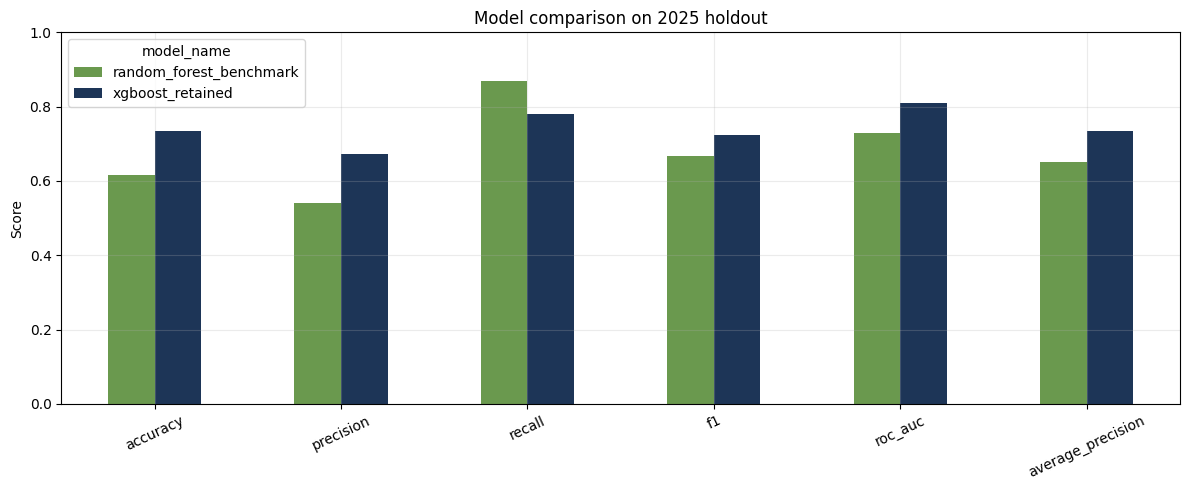

In [6]:
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
comparison_plot = comparison.set_index("model_name")[metric_columns].T

fig, ax = plt.subplots(figsize=(12, 5))
comparison_plot.plot(kind="bar", ax=ax, color=["#6A994E", "#1D3557"])
ax.set_title("Model comparison on 2025 holdout")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

We can see that the Random Forest covers a large number of true transfers, but at the cost of generating a large number of false positives. XGBoost appears to be more balanced: it has better accuracy, better precision, a higher AUC and better average precision.

## ROC Curves and Precision-Recall

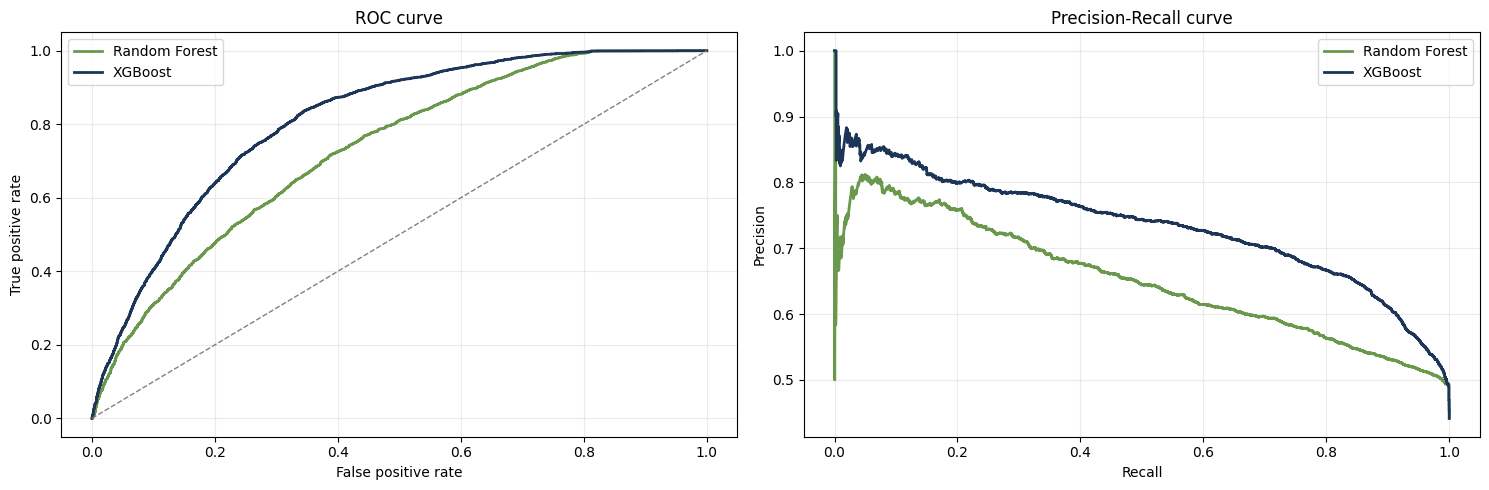

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for model_name, prediction_table, color in [
    ("Random Forest", rf_predictions, "#6A994E"),
    ("XGBoost", xgb_predictions, "#1D3557"),
]:
    fpr, tpr, _ = roc_curve(prediction_table["target"], prediction_table["transfer_probability"])
    precision, recall, _ = precision_recall_curve(prediction_table["target"], prediction_table["transfer_probability"])
    axes[0].plot(fpr, tpr, label=model_name, color=color, linewidth=2)
    axes[1].plot(recall, precision, label=model_name, color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

axes[1].set_title("Precision-Recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()

## Confusion matrixs

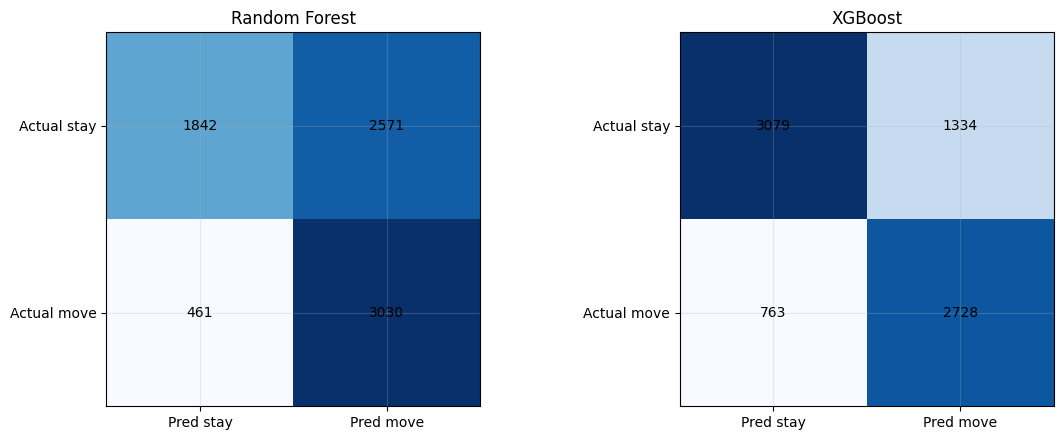

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, model_name, prediction_table in [
    (axes[0], "Random Forest", rf_predictions),
    (axes[1], "XGBoost", xgb_predictions),
]:
    matrix = confusion_matrix(prediction_table["target"], prediction_table["predicted_label"])
    ax.imshow(matrix, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred stay", "Pred move"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Actual stay", "Actual move"])

    for row_index in range(2):
        for column_index in range(2):
            ax.text(column_index, row_index, matrix[row_index, column_index], ha="center", va="center", color="black")

plt.tight_layout()

In [9]:
error_summary = []

for model_name, prediction_table in [
    ("random_forest_benchmark", rf_predictions),
    ("xgboost_retained", xgb_predictions),
]:
    counts = prediction_table["error_type"].value_counts()
    error_summary.append(
        {
            "model_name": model_name,
            "correct": counts.get("correct", 0),
            "false_positive": counts.get("false_positive", 0),
            "false_negative": counts.get("false_negative", 0),
        }
    )

pd.DataFrame(error_summary)

,model_name,correct,false_positive,false_negative
0,random_forest_benchmark,4872,2571,461
1,xgboost_retained,5807,1334,763


It’s important to remember that a model predicting transferability can perform well in the rankings whilst still producing a lot of false positives, as many players have plausible profiles without actually moving clubs that summer.

## Reading

For our use case, we have to checl the top of the rankings: how many actual transfers there are in the top 50, 100 and 250

In [10]:
ranking_rows = []

for model_name, prediction_table in [
    ("random_forest_benchmark", rf_predictions),
    ("xgboost_retained", xgb_predictions),
]:
    sorted_predictions = prediction_table.sort_values("transfer_probability", ascending=False)
    base_rate = prediction_table["target"].mean()

    for k in [50, 100, 250]:
        ranking_rows.append(
            {
                "model_name": model_name,
                "k": k,
                "precision_at_k": sorted_predictions.head(k)["target"].mean(),
                "true_movers_in_top_k": int(sorted_predictions.head(k)["target"].sum()),
                "base_rate": base_rate,
            }
        )

ranking_table = pd.DataFrame(ranking_rows)
ranking_table

,model_name,k,precision_at_k,true_movers_in_top_k,base_rate
0,random_forest_benchmark,50,0.700,35,0.441675
1,random_forest_benchmark,100,0.750,75,0.441675
2,random_forest_benchmark,250,0.804,201,0.441675
3,xgboost_retained,50,0.840,42,0.441675
4,xgboost_retained,100,0.870,87,0.441675
5,xgboost_retained,250,0.852,213,0.441675


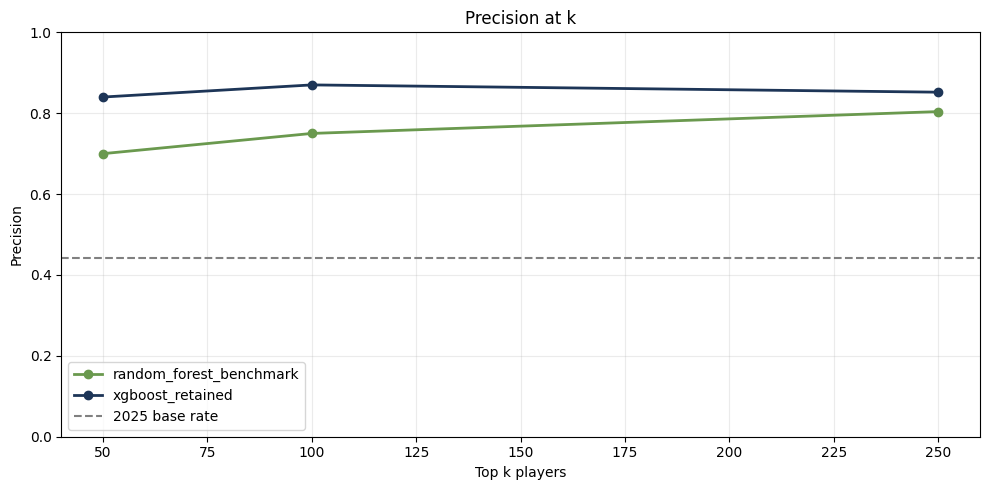

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

for model_name, color in [("random_forest_benchmark", "#6A994E"), ("xgboost_retained", "#1D3557")]:
    model_ranking = ranking_table.loc[ranking_table["model_name"] == model_name]
    ax.plot(model_ranking["k"], model_ranking["precision_at_k"], marker="o", linewidth=2, label=model_name, color=color)

ax.axhline(xgb_predictions["target"].mean(), linestyle="--", color="grey", label="2025 base rate")
ax.set_title("Precision at k")
ax.set_xlabel("Top k players")
ax.set_ylabel("Precision")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()

## Top predictions and errors

In [12]:
xgb_predictions.head(25)

,player_id,player_name,season_name,summer_year,target,transfer_probability,predicted_label,error_type
0,398742,Tommaso Spaviero,24/25,2025,1,0.930325,1,correct
1,930944,Tommaso Ghirardello,24/25,2025,1,0.925209,1,correct
2,676422,Samuele Sorrentino,24/25,2025,1,0.921931,1,correct
3,840426,João Lima,24/25,2025,1,0.917080,1,correct
4,1028507,Óscar Vacas,24/25,2025,1,0.914706,1,correct
5,391066,Giuseppe Montaperto,24/25,2025,1,0.912171,1,correct
6,315856,Christian Capone,24/25,2025,1,0.910879,1,correct
7,610909,Oriol Martí,24/25,2025,1,0.909396,1,correct
8,805954,Manuel Garavini,24/25,2025,1,0.909089,1,correct
9,284000,Carlos Júnior,24/25,2025,0,0.907877,1,false_positive


In [13]:
xgb_predictions.loc[xgb_predictions["error_type"] == "false_positive"].head(20)

,player_id,player_name,season_name,summer_year,target,transfer_probability,predicted_label,error_type
9,284000,Carlos Júnior,24/25,2025,0,0.907877,1,false_positive
11,1037696,Thomas Orfeini,24/25,2025,0,0.903846,1,false_positive
21,1006089,Francesco Bova,24/25,2025,0,0.888799,1,false_positive
26,935738,Antonio Coppola,24/25,2025,0,0.886192,1,false_positive
31,536112,Luca Manca,24/25,2025,0,0.883847,1,false_positive
34,215649,Mirko Marić,24/25,2025,0,0.882286,1,false_positive
39,600730,José González,24/25,2025,0,0.881398,1,false_positive
46,202977,Luca Iotti,24/25,2025,0,0.876878,1,false_positive
53,704554,Santiago Muñóz,24/25,2025,0,0.876196,1,false_positive
77,610622,Urko Izeta,24/25,2025,0,0.868893,1,false_positive


In [14]:
xgb_predictions.loc[xgb_predictions["error_type"] == "false_negative"].sort_values("transfer_probability", ascending=True).head(20)

,player_id,player_name,season_name,summer_year,target,transfer_probability,predicted_label,error_type
7698,126161,Unknown Player,24/25,2025,1,0.009800,0,false_negative
7431,515112,Unknown Player,24/25,2025,1,0.012971,0,false_negative
7121,55000,Unknown Player,24/25,2025,1,0.021769,0,false_negative
7085,215167,Unknown Player,24/25,2025,1,0.027012,0,false_negative
7067,577381,Unknown Player,24/25,2025,1,0.034912,0,false_negative
7065,542458,Unknown Player,24/25,2025,1,0.037014,0,false_negative
7063,748720,Unknown Player,24/25,2025,1,0.039658,0,false_negative
7062,226971,Unknown Player,24/25,2025,1,0.041158,0,false_negative
7056,696348,Unknown Player,24/25,2025,1,0.050879,0,false_negative
7046,816502,Unknown Player,24/25,2025,1,0.062539,0,false_negative


## Features importances

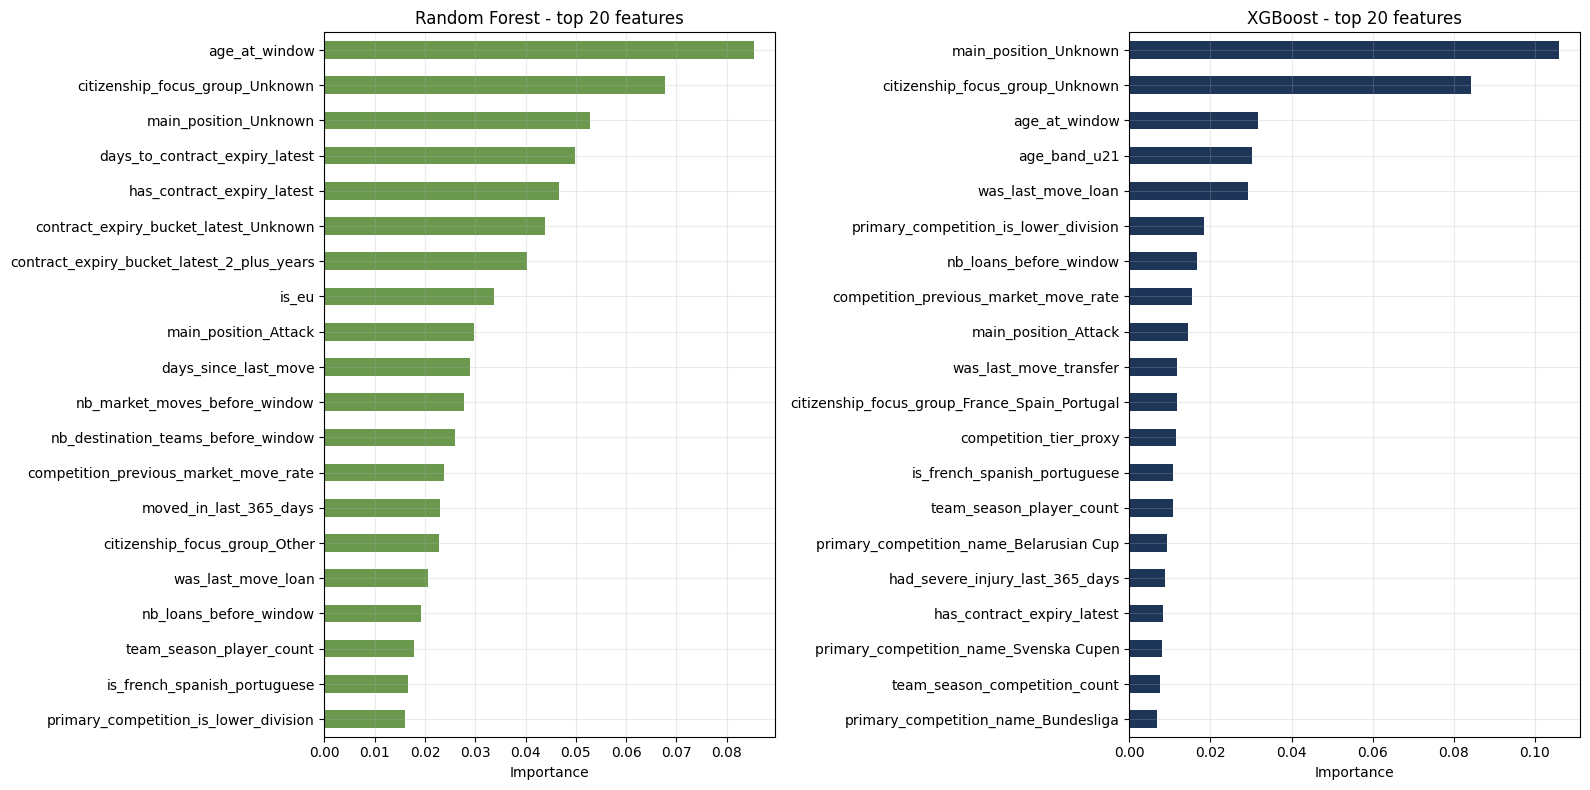

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

rf_importance.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature_name",
    y="importance",
    ax=axes[0],
    color="#6A994E",
    legend=False,
)
axes[0].set_title("Random Forest - top 20 features")
axes[0].set_xlabel("Importance")
axes[0].set_ylabel("")

xgb_importance.head(20).sort_values("importance").plot(
    kind="barh",
    x="feature_name",
    y="importance",
    ax=axes[1],
    color="#1D3557",
    legend=False,
)
axes[1].set_title("XGBoost - top 20 features")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("")

plt.tight_layout()

In [16]:
high_cardinality_tokens = ["team", "club", "competition", "league"]

importance_check_rows = []

for model_name, importance_table in [
    ("random_forest_benchmark", rf_importance),
    ("xgboost_retained", xgb_importance),
]:
    top_25 = importance_table.head(25).copy()
    high_cardinality_mask = top_25["feature_name"].str.lower().str.contains("|".join(high_cardinality_tokens), regex=True)
    importance_check_rows.append(
        {
            "model_name": model_name,
            "top_25_high_cardinality_count": int(high_cardinality_mask.sum()),
            "top_25_high_cardinality_share": float(high_cardinality_mask.mean()),
        }
    )

pd.DataFrame(importance_check_rows)

,model_name,top_25_high_cardinality_count,top_25_high_cardinality_share
0,random_forest_benchmark,7,0.28
1,xgboost_retained,11,0.44
